# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [4]:
corpus = """
Two lovers wander down to the shore
Hand in hand the evening before
The day that their hands will be joined
She enters and swims with the foam
He bids her come out and come home
But deeper and colder she goes
The silt of our wedding bed
The pebbles where you lay your head
Love, come in, the water is fine
When she is pulled beneath the rush
He waits and waves, his face aflush
'Til the pale imitation drifts up
The silt of our wedding bed
The pebbles where you lay your head
Love, come in
The minnows our witnesses
The cause of our sickness is
Love, come in, the water is fine
Blood runs thicker than water
Blood runs thicker than water
Blood runs thicker than water
But both feel the same when your eyes are closed
I am the river's daughter
I am the river's daughter
I am the river's daughter
And you'll be her son when we're both reposed
Blood runs thicker than water
Blood runs thicker than water
Blood runs thicker than water
But both feel the same when your eyes are closed
I am the river's daughter
I am the river's daughter
I am the river's daughter
And you'll be her son when we're both reposed
Blood runs thicker than water (the silt of our wedding bed)
Blood runs thicker than water
Blood runs thicker than water (the pebbles where you lay your head)
But both feel the same when your eyes are closed
I am the river's daughter (love, come in)
I am the river's daughter
I am the river's daughter (love, come in)
And you'll be her son when the water is fine
The minnows our witnesses (oh)
The cause of our sickness is
Love, come in
Love, come in
Love, come in, the water is fine
"""
print(corpus)


Two lovers wander down to the shore
Hand in hand the evening before
The day that their hands will be joined
She enters and swims with the foam
He bids her come out and come home
But deeper and colder she goes
The silt of our wedding bed
The pebbles where you lay your head
Love, come in, the water is fine
When she is pulled beneath the rush
He waits and waves, his face aflush
'Til the pale imitation drifts up
The silt of our wedding bed
The pebbles where you lay your head
Love, come in
The minnows our witnesses
The cause of our sickness is
Love, come in, the water is fine
Blood runs thicker than water
Blood runs thicker than water
Blood runs thicker than water
But both feel the same when your eyes are closed
I am the river's daughter
I am the river's daughter
I am the river's daughter
And you'll be her son when we're both reposed
Blood runs thicker than water
Blood runs thicker than water
Blood runs thicker than water
But both feel the same when your eyes are closed
I am the river's da

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [5]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 87
X shape: (259, 11)
y shape: (259,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [6]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [7]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [8]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


In [9]:
results = {}
results["Baseline"] = {
    "RNN Loss": rnn_history.history['loss'][-1],
    "RNN Acc": rnn_history.history['accuracy'][-1],

    "LSTM Loss": lstm_history.history['loss'][-1],
    "LSTM Acc": lstm_history.history['accuracy'][-1],

    "GRU Loss": gru_history.history['loss'][-1],
    "GRU Acc": gru_history.history['accuracy'][-1]
}

## 📉 Compare Training Loss

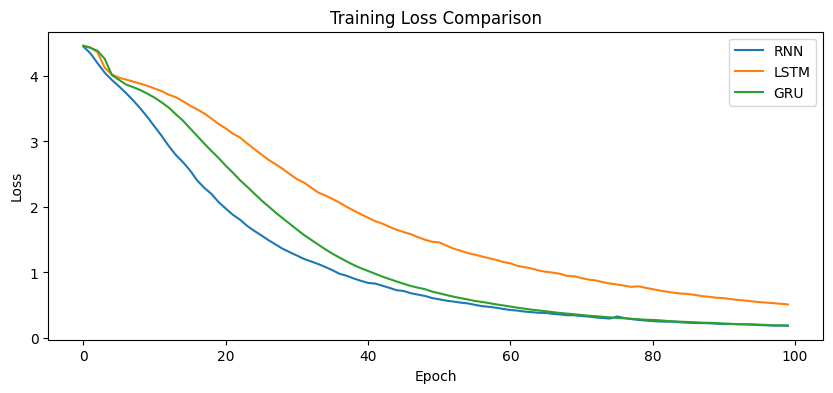

In [10]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [11]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [12]:
print("RNN :", generate_text(rnn_model, "blood runs", 5))
print("LSTM:", generate_text(lstm_model, "blood runs", 5))
print("GRU :", generate_text(gru_model, "blood runs", 5))

RNN : blood runs thicker than water the silt
LSTM: blood runs thicker than water the silt
GRU : blood runs thicker than water the silt


# Experiment 1: Increase Embedding Dimension

In [13]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


In [14]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


In [15]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


In [16]:
results["Embedding64"] = {
    "RNN Loss": rnn_history.history['loss'][-1],
    "RNN Acc": rnn_history.history['accuracy'][-1],

    "LSTM Loss": lstm_history.history['loss'][-1],
    "LSTM Acc": lstm_history.history['accuracy'][-1],

    "GRU Loss": gru_history.history['loss'][-1],
    "GRU Acc": gru_history.history['accuracy'][-1]
}

# Experiment 2: Increase Hidden Units

In [17]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


In [18]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


In [19]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


In [20]:
results["Units128"] = {
    "RNN Loss": rnn_history.history['loss'][-1],
    "RNN Acc": rnn_history.history['accuracy'][-1],

    "LSTM Loss": lstm_history.history['loss'][-1],
    "LSTM Acc": lstm_history.history['accuracy'][-1],

    "GRU Loss": gru_history.history['loss'][-1],
    "GRU Acc": gru_history.history['accuracy'][-1]
}

# Experiment 3: Increase Epochs

In [21]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


In [22]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


In [23]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


In [24]:
results["Epochs200"] = {
    "RNN Loss": rnn_history.history['loss'][-1],
    "RNN Acc": rnn_history.history['accuracy'][-1],

    "LSTM Loss": lstm_history.history['loss'][-1],
    "LSTM Acc": lstm_history.history['accuracy'][-1],

    "GRU Loss": gru_history.history['loss'][-1],
    "GRU Acc": gru_history.history['accuracy'][-1]
}

# Experiment 4: Generate Longer Text

In [25]:
print("RNN :", generate_text(rnn_model, "blood runs", 10))
print("LSTM:", generate_text(lstm_model, "blood runs", 10))
print("GRU :", generate_text(gru_model, "blood runs", 10))

RNN : blood runs thicker than water the silt of our wedding bed and
LSTM: blood runs thicker than water the pebbles where you lay your head
GRU : blood runs thicker than water the silt of our wedding bed bed


In [26]:
import pandas as pd

comparison_df = pd.DataFrame(results).T

print(comparison_df)

             RNN Loss   RNN Acc  LSTM Loss  LSTM Acc  GRU Loss   GRU Acc
Baseline     0.189809  0.957529   0.512126  0.915058  0.187308  0.953668
Embedding64  0.143955  0.953668   0.334866  0.953668  0.153337  0.961390
Units128     0.123504  0.953668   0.229111  0.953668  0.128464  0.957529
Epochs200    0.100049  0.953668   0.156789  0.957529  0.102956  0.957529


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**